# 美國 DOE 紀錄電力系統復電時間

DOE-417 電力停電資料為 DOE (Department of Energy, DOE) 對電力系統重大事件的紀錄 (以下為須申報內容) ，嚴重的電力事件，門檻高，作為判斷 **異常值** 的閥值相當合適，此筆記本著重於對 DOE-417 資料前處裡。

* 由於我們分析的資料為 BPA (Bonneville Power Administration) 其為 WECC 地區 (美國西岸) ，故會篩選出 WECC 的資料出來做處理

* 本篇主要計算出各年度的復電最久時間以做後續閥值判斷

* 其中復電時間為整個停電事件結束的時間，作為單一線路是否完成修復的閥值屬於保守估計

1. 1 小時內申報（Emergency Alert）

   * 實體攻擊導致重大中斷
   * 可申報的網路安全事件
   * 網路事件導致電力系統運作中斷
   * 輸配電系統完全停擺
   * 電力系統孤島（Islanding）
   * 單一事件造成 300 MW 以上穩定負載不受控損失（持續 15 分鐘以上）
   * 緊急政策下削減 100 MW 以上穩定負載
   * 全系統電壓降低 3% 以上
   * 公開呼籲節電以維持系統穩定

2. 6 小時內申報（Normal Report）

   * 可能影響電力系統的實體攻擊或破壞
   * 可能影響電力系統的網路事件
   * 超過 50,000 戶停電 1 小時以上
   * 燃料供應緊急狀況

3. 1 個工作天內申報（System Report）

   * 設施損毀或破壞
   * 單一事件造成 200 MW 以上穩定負載損失（針對尖峰需求 ≤ 3,000 MW 的機構）
   * 核電廠失去廠外電源
   * 輸電設備異常損失（3 個以上 BES 設施）
   * 控制中心失能或撤離
   * 電壓偏差 ≥ 10%（持續 15 分鐘以上）
   * 逆變器資源損失 500 MW 以上

# 1. 資料讀取

In [1]:
import pandas as pd
import datetime

# 讀取合併後的 DOE 資料
df_doe = pd.read_csv("raw_data/doe_data_merged.csv")

# Check
df_doe.head()

,Date Event Began,Time Event Began,Date of Restoration,Time of Restoration,Area Affected,NERC Region,Event Type,Demand Loss (MW),Number of Customers Affected,year,Month,Alert Criteria,Event Month
0,January,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2012,NaN,NaN,NaN
1,2012-01-04 00:00:00,12:14:00,2012-01-04 00:00:00,12:14:00,"Tacoma, Washington",WECC,Suspected physical attack,NaN,NaN,2012,NaN,NaN,NaN
2,2012-01-05 00:00:00,10:35:00,2012-01-05 00:00:00,12:25:00,"CSWS/AEP West territory, Oklahoma",SPP,Sabotage,0,0,2012,NaN,NaN,NaN
3,2012-01-05 00:00:00,10:28:00,2012-01-05 00:00:00,12:25:00,"Creek County, Oklahoma",SPP,Suspected physical attack,NaN,NaN,2012,NaN,NaN,NaN
4,2012-01-09 00:00:00,14:30:00,2012-01-09 00:00:00,15:30:00,"Watertown, Connecticut",NPCC,Vandalism,NaN,NaN,2012,NaN,NaN,NaN


# 2. 檢視資料狀況

* 檢視 missing data, duplicated data 狀況
* 重複值保留一筆資料
* missing data 等到主要要看事件起訖時間，其餘空值影響不大

In [2]:
# 確認欄位資訊
print("=== 基本資訊 ===")
print(df_doe.shape)
print()

# 空值
print("=== 空值統計 ===")
print(df_doe.isnull().sum())
print()

# 重複值
print("=== 重複值 ===")
print(f"重複筆數: {df_doe.duplicated().sum()}")

=== 基本資訊 ===
(3078, 13)

=== 空值統計 ===
Date Event Began                  33
Time Event Began                  47
Date of Restoration               47
Time of Restoration               47
Area Affected                     47
NERC Region                       73
Event Type                        47
Demand Loss (MW)                 144
Number of Customers Affected     131
year                               0
Month                            986
Alert Criteria                   638
Event Month                     2730
dtype: int64

=== 重複值 ===
重複筆數: 24


# 3. 處理重複值

In [3]:
# 移除重複值
df_doe = df_doe.drop_duplicates()
print(f"移除重複值後: {df_doe.shape}")

移除重複值後: (3054, 13)


# 4. 處理空值

In [4]:
# 移除起訖時間為空的資料
required_cols = ["Date Event Began", "Time Event Began", 
                 "Date of Restoration", "Time of Restoration"]
df_doe = df_doe.dropna(subset=required_cols)
print(f"移除起訖時間空值後: {df_doe.shape}")

移除起訖時間空值後: (2975, 13)


# 5. 計算各年度復電時間最大值

1. **篩選 WECC 地區**：從 DOE 資料中篩選 `NERC Region` 包含 `WECC` 的事件，對應 BPA 所在地區

2. **排除無效資料**：排除 `Date of Restoration` 或 `Time of Restoration` 為 `Unknown` 的筆數，以及 duration 為負值或無法計算的筆數

3. **計算 duration**：將事件起始時間與復電時間合併為 datetime，計算差值轉換為分鐘

4. **取各年度最大值**：依 `year` 分組，取每年 WECC 地區最長的復電時間作為該年度的 threshold 參考值

In [5]:
# 篩選 NERC Region 包含 WECC
df_wecc = df_doe[df_doe["NERC Region"].str.contains("WECC", na=False)].copy()

# AI 在讀取資料時有發現 Unknown 的資料，但在 WECC 沒有出現，此處依舊做防呆設計，排除 Unknown
df_wecc = df_wecc[df_wecc["Date of Restoration"] != "Unknown"]
df_wecc = df_wecc[df_wecc["Time of Restoration"] != "Unknown"]

# 將日期與時分合併，並轉成 datetime 格式
def parse_datetime(date_val, time_val):
    try:
        return pd.to_datetime(f"{date_val} {time_val}")
    except:
        return pd.NaT
    
# 新增欄位 : 停電時間
df_wecc["dt_begin"]   = df_wecc.apply(lambda r: parse_datetime(r["Date Event Began"],    r["Time Event Began"]),   axis=1)
# 新增欄位 : 復電時間
df_wecc["dt_restore"] = df_wecc.apply(lambda r: parse_datetime(r["Date of Restoration"], r["Time of Restoration"]), axis=1)
# 事件詞序時間
df_wecc["duration_minutes"] = (df_wecc["dt_restore"] - df_wecc["dt_begin"]).dt.total_seconds() / 60

# 防呆 : 排除負值與無法計算的筆數
df_wecc = df_wecc[df_wecc["duration_minutes"] > 0].dropna(subset=["duration_minutes"])

# 各年度最大復電時間
df_threshold = df_wecc.groupby("year")["duration_minutes"].max().reset_index()
df_threshold.columns = ["year", "max_duration_minutes"]
df_threshold["max_duration_hours"] = df_threshold["max_duration_minutes"] / 60
df_threshold["max_duration_days"]  = df_threshold["max_duration_minutes"] / 1440

df_threshold

,year,max_duration_minutes,max_duration_hours,max_duration_days
0,2012,3100.0,51.666667,2.152778
1,2013,4390.0,73.166667,3.048611
2,2014,5690.0,94.833333,3.951389
3,2015,8880.0,148.000000,6.166667
4,2016,49487.0,824.783333,34.365972
5,2017,12207.0,203.450000,8.477083
6,2018,29356.0,489.266667,20.386111
7,2019,7385.0,123.083333,5.128472
8,2020,5520.0,92.000000,3.833333
9,2021,11295.0,188.250000,7.843750


# 6. 統計數據

In [6]:
print("=== WECC 各年度最大復電時間統計 ===")
print(f"資料年份範圍: {df_threshold['year'].min()} ~ {df_threshold['year'].max()}")
print(f"平均最大復電時間: {df_threshold['max_duration_days'].mean():.2f} 天")
print(f"中位數最大復電時間: {df_threshold['max_duration_days'].median():.2f} 天")
print(f"最長復電時間: {df_threshold['max_duration_days'].max():.2f} 天 ({df_threshold.loc[df_threshold['max_duration_days'].idxmax(), 'year']} 年)")
print(f"最短復電時間: {df_threshold['max_duration_days'].min():.2f} 天 ({df_threshold.loc[df_threshold['max_duration_days'].idxmin(), 'year']} 年)")

=== WECC 各年度最大復電時間統計 ===
資料年份範圍: 2012 ~ 2023
平均最大復電時間: 9.39 天
中位數最大復電時間: 5.65 天
最長復電時間: 34.37 天 (2016 年)
最短復電時間: 2.15 天 (2012 年)


# 7. 視覺化

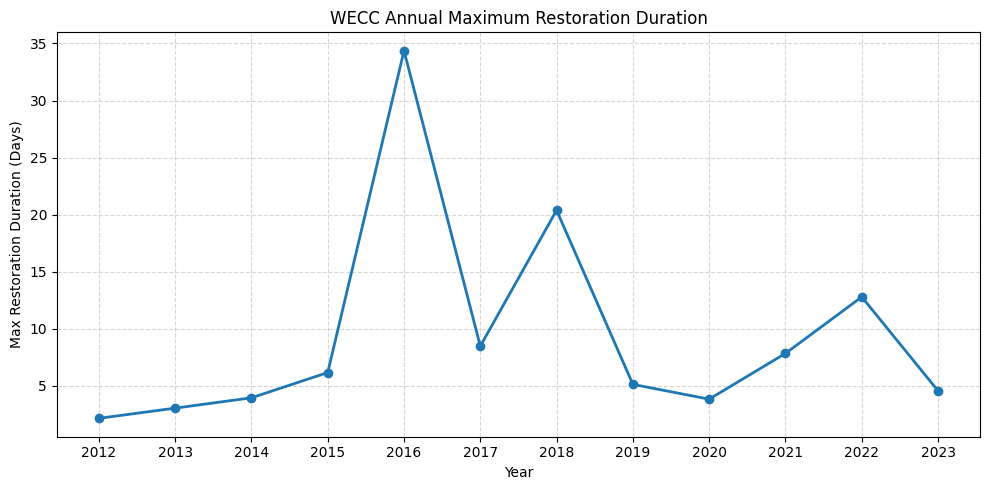

In [7]:
import matplotlib.pyplot as plt

# 繪製各年度最大復電時間折線圖
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(df_threshold["year"], df_threshold["max_duration_days"],
        marker="o", linewidth=2, markersize=6)

ax.set_xlabel("Year")
ax.set_ylabel("Max Restoration Duration (Days)")
ax.set_title("WECC Annual Maximum Restoration Duration")
ax.set_xticks(df_threshold["year"])
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# 8. 檢視 TOP-K 事件

* 檢視前 10 名嚴重的事件，看一下 code 有沒有問題，也了解一下具題事件內容
 
* 第 1 名事件說明 : 著名的 Aliso Canyon 天然氣洩漏事件，也是目前最嚴重的一筆（49,487 分鐘，約 34 天）。
  
>事件背景：2015 年 10 月，南加州天然氣公司（SoCalGas）位於洛杉磯 Porter Ranch 的 Aliso Canyon 地下儲氣設施發生大規模甲烷洩漏，這是美國史上最大的天然氣洩漏事件。洩漏持續到 2016 年 2 月才封堵，共釋放約 109,000 公噸甲烷，近萬戶居民被迫撤離。
>由於 Aliso Canyon 是南加州最大的天然氣儲存設施，洩漏後儲量大幅受限，導致南加州電廠燃氣供應吃緊。DOE 記錄的這筆事件（2016/03/03 ~ 2016/04/06，San Bernardino County，Fuel Supply Deficiency）正是 Aliso Canyon 後續影響的延伸，燃氣供應不足迫使電力系統長期處於緊急狀態。

In [8]:
df_wecc.nlargest(10, "duration_minutes").reset_index(drop=True)

,Date Event Began,Time Event Began,Date of Restoration,Time of Restoration,Area Affected,NERC Region,Event Type,Demand Loss (MW),Number of Customers Affected,year,Month,Alert Criteria,Event Month,dt_begin,dt_restore,duration_minutes
0,2016-03-03 00:00:00,11:00:00,2016-04-06 00:00:00,19:47:00,California: San Bernardino County;,WECC,Fuel Supply Deficiency,0,0,2016,March,Fuel supply emergencies that could impact elec...,NaN,2016-03-03 11:00:00,2016-04-06 19:47:00,49487.0
1,11/08/2018,07:16:00,11/28/2018,16:32:00,California: Butte County;,WECC,Natural Disaster/Transmission Interruption,32,11844,2018,November,Electrical System Separation (Islanding) where...,NaN,2018-11-08 07:16:00,2018-11-28 16:32:00,29356.0
2,05/18/2022,17:00:00,05/31/2022,12:00:00,New Mexico: San Juan County;,WECC,Fuel Supply Deficiency,560,0,2022,May,Fuel supply emergencies that could impact elec...,NaN,2022-05-18 17:00:00,2022-05-31 12:00:00,18420.0
3,10/29/2018,05:00:00,11/07/2018,07:00:00,California: Shasta County;,WECC,Vandalism,0,0,2018,October,Physical attack that could potentially impact ...,NaN,2018-10-29 05:00:00,2018-11-07 07:00:00,13080.0
4,10/09/2017,02:03:00,10/17/2017,13:30:00,California:,WECC,Severe Weather/Transmission Interruption,177,117900,2017,October,"Loss of electric service to more than 50,000 c...",NaN,2017-10-09 02:03:00,2017-10-17 13:30:00,12207.0
5,12/26/2018,01:00:00,01/03/2019,10:27:00,California: Kern County;,WECC,Vandalism,0,0,2018,December,Physical attack that could potentially impact ...,NaN,2018-12-26 01:00:00,2019-01-03 10:27:00,12087.0
6,02/12/2021,21:00:00,02/20/2021,17:15:00,"Oregon: Clackamas County, Marion County, Polk ...",WECC,Severe Weather,Unknown,300187,2021,February,"Loss of electric service to more than 50,000 c...",NaN,2021-02-12 21:00:00,2021-02-20 17:15:00,11295.0
7,2015-08-29 00:00:00,11:00:00,2015-09-04 00:00:00,15:00:00,"King County, Skagit County, Whatcom County, Ki...",WECC,Severe Weather,250,250000,2015,August,"Loss of electric service to more than 50,000 c...",NaN,2015-08-29 11:00:00,2015-09-04 15:00:00,8880.0
8,2017-02-17 00:00:00,08:09:00,2017-02-22 00:00:00,19:30:00,California,WECC,Severe Weather,254,169250,2017,February,"Loss of electric service to more than 50,000 c...",NaN,2017-02-17 08:09:00,2017-02-22 19:30:00,7881.0
9,01/08/2017,09:07:00,01/13/2017,14:30:00,California,WECC,Severe Weather,Unknown,106000,2017,January,"Loss of electric service to more than 50,000 c...",NaN,2017-01-08 09:07:00,2017-01-13 14:30:00,7523.0


## 年度 TOP-K

In [9]:
df_top3 = df_wecc.groupby("year")["duration_minutes"].nlargest(3).reset_index()[["year", "duration_minutes"]].copy()
df_top3

,year,duration_minutes
0,2012,3100.0
1,2012,2880.0
2,2012,2878.0
3,2013,4390.0
4,2013,3842.0
5,2013,3698.0
6,2014,5690.0
7,2014,4140.0
8,2014,3918.0
9,2015,8880.0


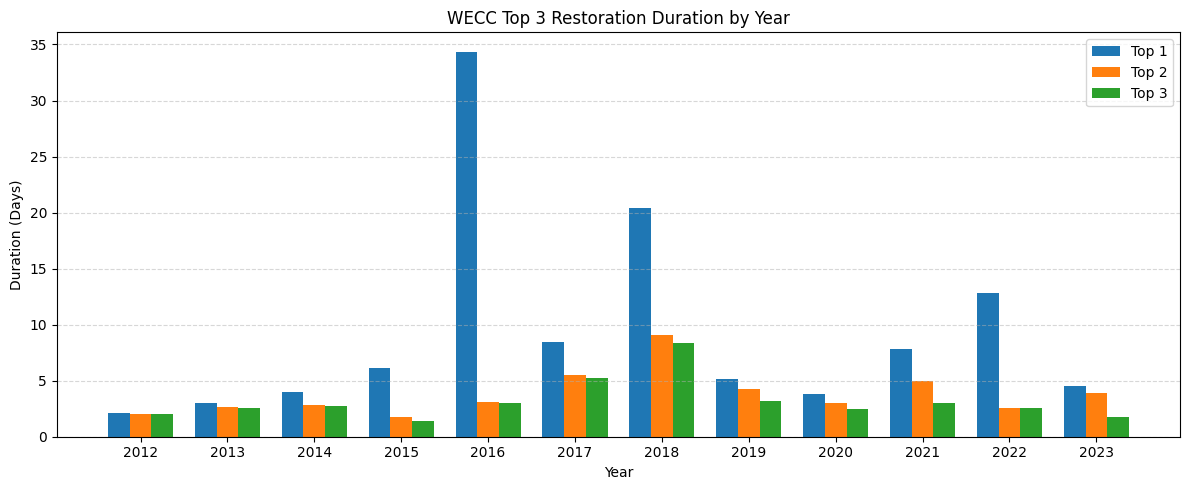

In [10]:
import matplotlib.pyplot as plt
import numpy as np

years = df_top3["year"].unique()
ranks = df_top3.groupby("year").cumcount()

x = np.arange(len(years))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))

for rank in range(3):
    data = df_top3[ranks == rank]["duration_minutes"] / 1440
    ax.bar(x + rank * width, data, width=width, label=f"Top {rank + 1}")

ax.set_xlabel("Year")
ax.set_ylabel("Duration (Days)")
ax.set_title("WECC Top 3 Restoration Duration by Year")
ax.set_xticks(x + width)
ax.set_xticklabels(years)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5, axis="y")

plt.tight_layout()
plt.show()

# 9. 存檔

In [11]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
df_wecc.to_csv(os.path.join(output_dir, "doe_wecc.csv"), index=False)